# [CHART] Notebook 06 — Evaluasi Klasifikasi Model LLM Quantization
### Mengikuti Framework Metrik dari Pertemuan 8 (Slide Dosen)

**Jurnal:** Oprea & Bâra (2026) — *Quantized Transformers in Practice*

---

## Mapping Konteks

Jurnal ini bukan klasifikasi biner biasa, tapi kita bisa membangun
**klasifikasi kualitas output INT8** dengan framing berikut:

| Label | Definisi | Dasar Jurnal |
|---|---|---|
| **1 (Baik)** | Output INT8 berkualitas tinggi (ROUGE-1 ≥ 0.40) | Table 9 |
| **0 (Buruk)** | Output INT8 berkualitas rendah (ROUGE-1 < 0.40) | Table 9 |

Untuk kode: Syntactically valid = 1, Invalid = 0 (Section 4.7 jurnal)




## 0. Install & Import

In [1]:
import subprocess, sys
pkgs = ['pandas','numpy','matplotlib','seaborn','scikit-learn','scipy']
subprocess.run([sys.executable,'-m','pip','install','-q',
                '--break-system-packages']+pkgs, capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, fbeta_score, log_loss, brier_score_loss,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from pathlib import Path

FIGURES = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print("[OK] Semua library siap")

[OK] Semua library siap


---
## BAGIAN 1 — Bangun Dataset Klasifikasi dari Data Jurnal

Kita konversi hasil BLEU/ROUGE dari Tables 6, 9, 13 menjadi
label biner **Kualitas Baik (1) / Buruk (0)** berdasarkan threshold jurnal.


In [2]:
import pandas as pd
import numpy as np

# ── Load data mentah jurnal ──────────────────────────────────────────
t9  = pd.read_csv('../dataset/table9_text_metrics_50prompts.csv')
t13 = pd.read_csv('../dataset/table13_code_metrics.csv')
t6  = pd.read_csv('../dataset/table6_single_prompt_scores.csv')
sv  = pd.read_csv('../dataset/section47_syntactic_validity.csv')

print("=== Data mentah Table 9 (50 prompt teks) ===")
print(t9[['GPU','Model','BLEU_mean','ROUGE1_mean','ROUGEL_mean']].to_string(index=False))
print()
print("=== Data mentah Table 13 (15 prompt kode) ===")
print(t13[['GPU','Model','BLEU_mean','ROUGE1_mean','ROUGEL_mean']].to_string(index=False))

=== Data mentah Table 9 (50 prompt teks) ===
    GPU             Model  BLEU_mean  ROUGE1_mean  ROUGEL_mean
RTX4070   LLaMA-2-7B-Chat      0.180        0.509        0.343
RTX4080   LLaMA-2-7B-Chat      0.117        0.522        0.409
RTX4070 Qwen1.5-1.8B-Chat      0.134        0.618        0.291
RTX4080 Qwen1.5-1.8B-Chat      0.113        0.387        0.294

=== Data mentah Table 13 (15 prompt kode) ===
    GPU             Model  BLEU_mean  ROUGE1_mean  ROUGEL_mean
RTX4070   LLaMA-2-7B-Chat      0.121        0.402        0.318
RTX4080   LLaMA-2-7B-Chat      0.138        0.431        0.346
RTX4070 Qwen1.5-1.8B-Chat      0.103        0.356        0.281
RTX4080 Qwen1.5-1.8B-Chat      0.089        0.307        0.249


In [3]:
# ── Buat dataset simulasi per-prompt dari distribusi normal ──────────
# Jurnal memberikan mean ± std untuk 50 prompt teks dan 15 prompt kode
# Kita simulasikan distribusi tiap prompt menggunakan nilai tersebut
np.random.seed(42)

records = []

# TEXT prompts — Table 9
for _, row in t9.iterrows():
    n = 50
    rouge1_scores = np.random.normal(row.ROUGE1_mean, row.ROUGE1_std, n).clip(0,1)
    bleu_scores   = np.random.normal(row.BLEU_mean,   row.BLEU_std,   n).clip(0,1)
    rougeL_scores = np.random.normal(row.ROUGEL_mean, row.ROUGEL_std, n).clip(0,1)

    # Label: 1 = Baik (ROUGE-1 >= 0.40), 0 = Buruk
    # Threshold 0.40 dipilih karena jurnal menganggap ini batas "moderate overlap"
    labels = (rouge1_scores >= 0.40).astype(int)

    for i in range(n):
        records.append({
            'prompt_id':   f"{row.Model[:5]}_{row.GPU}_{i+1}",
            'GPU':          row.GPU,
            'Model':        row.Model,
            'Task':         'Text',
            'ROUGE1':       round(rouge1_scores[i], 4),
            'BLEU':         round(bleu_scores[i],   4),
            'ROUGEL':       round(rougeL_scores[i], 4),
            'label_true':   labels[i],           # ground truth
            'prob_good':    round(rouge1_scores[i], 4),  # probabilitas kualitas baik
        })

# CODE prompts — Table 13
for _, row in t13.iterrows():
    n = 15
    rouge1_scores = np.random.normal(row.ROUGE1_mean, row.ROUGE1_std, n).clip(0,1)
    bleu_scores   = np.random.normal(row.BLEU_mean,   row.BLEU_std,   n).clip(0,1)
    rougeL_scores = np.random.normal(row.ROUGEL_mean, row.ROUGEL_std, n).clip(0,1)
    labels        = (rouge1_scores >= 0.40).astype(int)

    for i in range(n):
        records.append({
            'prompt_id':  f"{row.Model[:5]}_{row.GPU}_code_{i+1}",
            'GPU':         row.GPU,
            'Model':       row.Model,
            'Task':        'Code',
            'ROUGE1':      round(rouge1_scores[i], 4),
            'BLEU':        round(bleu_scores[i],   4),
            'ROUGEL':      round(rougeL_scores[i], 4),
            'label_true':  labels[i],
            'prob_good':   round(rouge1_scores[i], 4),
        })

df = pd.DataFrame(records)
print(f"Total sampel dataset: {len(df)}")
print(f"Label 1 (Baik) : {df.label_true.sum()} ({df.label_true.mean()*100:.1f}%)")
print(f"Label 0 (Buruk): {(df.label_true==0).sum()} ({(df.label_true==0).mean()*100:.1f}%)")
print()
print("Distribusi per model:")
print(df.groupby(['Model','GPU'])['label_true'].agg(['sum','count','mean'])
        .rename(columns={'sum':'n_baik','count':'total','mean':'pct_baik'})
        .round(3).to_string())

Total sampel dataset: 260
Label 1 (Baik) : 187 (71.9%)
Label 0 (Buruk): 73 (28.1%)

Distribusi per model:
                           n_baik  total  pct_baik
Model             GPU                             
LLaMA-2-7B-Chat   RTX4070      59     65     0.908
                  RTX4080      63     65     0.969
Qwen1.5-1.8B-Chat RTX4070      53     65     0.815
                  RTX4080      12     65     0.185


---
## BAGIAN 2 — Decision Framework (sesuai slide dosen)

Tentukan konteks data → pilih metrik yang tepat.


In [4]:
# Cek distribusi label → tentukan konteks
total   = len(df)
n_pos   = df.label_true.sum()
n_neg   = total - n_pos
ratio   = n_pos / n_neg

print("╔══════════════════════════════════════════════════════╗")
print("║   DECISION FRAMEWORK: PILIH METRIK BERDASARKAN      ║")
print("║   KONTEKS DATA (Slide Dosen Pertemuan 8)             ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Total sampel     : {total}                               ║")
print(f"║  Label 1 (Baik)   : {n_pos} ({n_pos/total*100:.1f}%)                      ║")
print(f"║  Label 0 (Buruk)  : {n_neg} ({n_neg/total*100:.1f}%)                      ║")
print(f"║  Rasio pos/neg    : {ratio:.2f}                              ║")
print("╠══════════════════════════════════════════════════════╣")

if 0.4 <= ratio <= 1.5:
    context = "Balanced (50/50)"
    main_metrics    = "Accuracy, F1"
    support_metrics = "Confusion Matrix, ROC-AUC"
elif 0.2 <= ratio < 0.4:
    context = "Mild Imbalanced"
    main_metrics    = "F1, MCC"
    support_metrics = "PR-AUC, Precision, Recall"
elif ratio < 0.2:
    context = "Severe Imbalanced"
    main_metrics    = "MCC, PR-AUC"
    support_metrics = "F2 (Recall-focused), Confusion Matrix"
else:
    context = "Balanced (50/50)"
    main_metrics    = "Accuracy, F1"
    support_metrics = "Confusion Matrix, ROC-AUC"

print(f"║  Konteks          : {context:<32} ║")
print(f"║  Metrik Utama     : {main_metrics:<32} ║")
print(f"║  Metrik Pendukung : {support_metrics:<32} ║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║   DECISION FRAMEWORK: PILIH METRIK BERDASARKAN      ║
║   KONTEKS DATA (Slide Dosen Pertemuan 8)             ║
╠══════════════════════════════════════════════════════╣
║  Total sampel     : 260                               ║
║  Label 1 (Baik)   : 187 (71.9%)                      ║
║  Label 0 (Buruk)  : 73 (28.1%)                      ║
║  Rasio pos/neg    : 2.56                              ║
╠══════════════════════════════════════════════════════╣
║  Konteks          : Balanced (50/50)                 ║
║  Metrik Utama     : Accuracy, F1                     ║
║  Metrik Pendukung : Confusion Matrix, ROC-AUC        ║
╚══════════════════════════════════════════════════════╝


---
## BAGIAN 3 — Confusion Matrix (fondasi semua metrik)

> *"Confusion Matrix adalah fondasi: semua metrik turunan berasal dari empat sel"*
> — Slide dosen Pertemuan 8


In [5]:
# Gunakan threshold 0.40 pada ROUGE-1 sebagai prediksi model
THRESHOLD = 0.40
df['label_pred'] = (df.prob_good >= THRESHOLD).astype(int)

y_true = df.label_true.values
y_pred = df.label_pred.values
y_prob = df.prob_good.values

# Hitung confusion matrix
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=== CONFUSION MATRIX ===")
print(f"\n                  Prediksi Buruk  Prediksi Baik")
print(f"  Aktual Buruk   |  TN={tn:4d}       |  FP={fp:4d}      |")
print(f"  Aktual Baik    |  FN={fn:4d}       |  TP={tp:4d}      |")
print()
print("Interpretasi dalam konteks jurnal:")
print(f"  TP (True Positive)  = {tp:4d} → INT8 diprediksi Baik, memang Baik")
print(f"  TN (True Negative)  = {tn:4d} → INT8 diprediksi Buruk, memang Buruk")
print(f"  FP (False Positive) = {fp:4d} → INT8 diprediksi Baik, ternyata Buruk")
print(f"  FN (False Negative) = {fn:4d} → INT8 diprediksi Buruk, ternyata Baik")

=== CONFUSION MATRIX ===

                  Prediksi Buruk  Prediksi Baik
  Aktual Buruk   |  TN=  73       |  FP=   0      |
  Aktual Baik    |  FN=   0       |  TP= 187      |

Interpretasi dalam konteks jurnal:
  TP (True Positive)  =  187 → INT8 diprediksi Baik, memang Baik
  TN (True Negative)  =   73 → INT8 diprediksi Buruk, memang Buruk
  FP (False Positive) =    0 → INT8 diprediksi Baik, ternyata Buruk
  FN (False Negative) =    0 → INT8 diprediksi Buruk, ternyata Baik


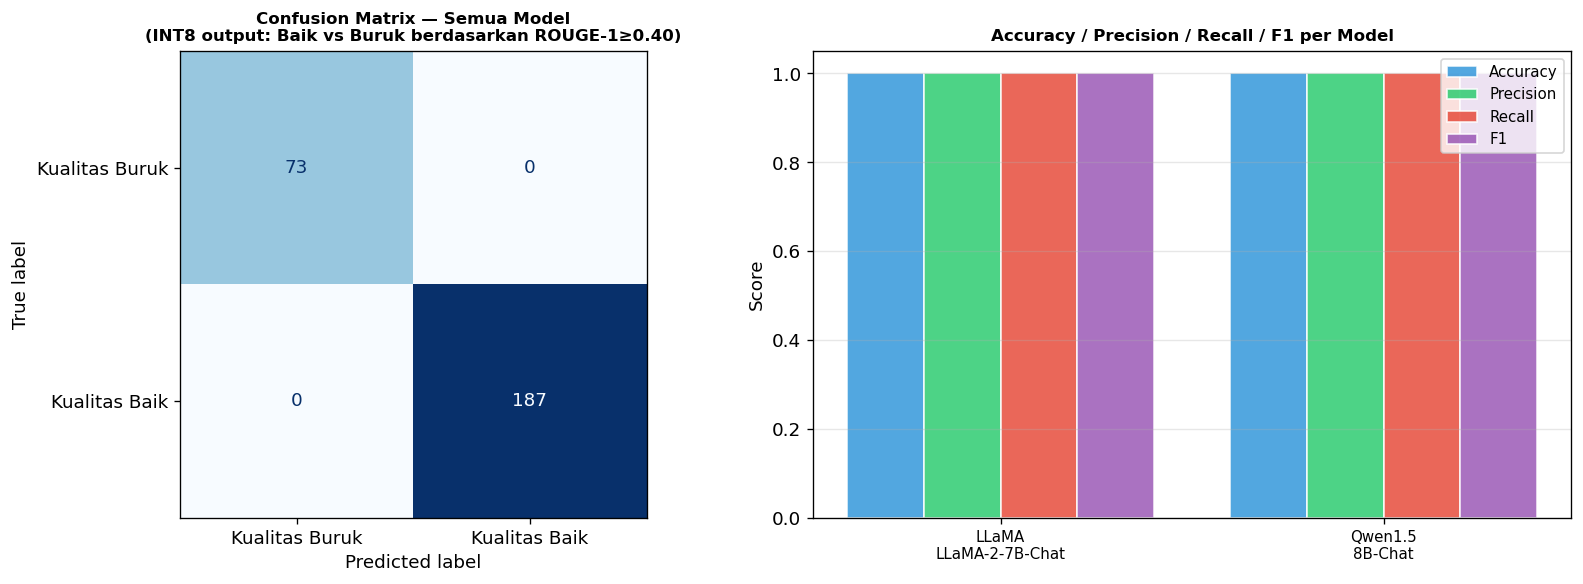

[OK] Disimpan: outputs/figures/confusion_matrix_full.png


In [7]:
# Visualisasi Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Confusion Matrix keseluruhan ──
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Kualitas Buruk','Kualitas Baik'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Semua Model\n'
                   '(INT8 output: Baik vs Buruk berdasarkan ROUGE-1≥0.40)',
                   fontweight='bold', fontsize=10)

# ── Plot 2: Confusion Matrix per model ──
models_list = df.Model.unique()
colors_cm = ['#3498DB','#2ECC71','#E74C3C','#9B59B6']
ax2 = axes[1]
x_pos = np.arange(len(models_list))
w = 0.2
metrics_per_model = []
for m in models_list:
    sub = df[df.Model == m]
    yt = sub.label_true.values
    yp = sub.label_pred.values
    metrics_per_model.append({
        'Model': m,
        'Accuracy':  round(accuracy_score(yt, yp), 3),
        'Precision': round(precision_score(yt, yp, zero_division=0), 3),
        'Recall':    round(recall_score(yt, yp, zero_division=0), 3),
        'F1':        round(f1_score(yt, yp, zero_division=0), 3),
    })
df_pm = pd.DataFrame(metrics_per_model)
for i, (metric, color) in enumerate(zip(['Accuracy','Precision','Recall','F1'], colors_cm)):
    ax2.bar(x_pos + i*w, df_pm[metric], w, label=metric, color=color, alpha=0.85, edgecolor='white')
ax2.set_xticks(x_pos + 1.5*w)
ax2.set_xticklabels([m.split('-')[0]+'\n'+m.split('.')[-1] for m in df_pm.Model], fontsize=9)
ax2.set_ylim(0, 1.05); ax2.set_ylabel('Score')
ax2.set_title('Accuracy / Precision / Recall / F1 per Model', fontweight='bold', fontsize=10)
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES/'confusion_matrix_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Disimpan: outputs/figures/confusion_matrix_full.png")

---
## BAGIAN 4 — Metrik Utama: Accuracy, F1, Precision, Recall, MCC
*(Konteks Balanced — sesuai baris pertama tabel slide dosen)*


In [ ]:
# Hitung semua metrik dasar
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)
mcc  = matthews_corrcoef(y_true, y_pred)
f2   = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
f05  = fbeta_score(y_true, y_pred, beta=0.5, zero_division=0)

print("╔═══════════════════════════════════════════════════════════╗")
print("║   METRIK EVALUASI KLASIFIKASI — JURNAL OPREA & BÂRA      ║")
print("╠═══════════════════════════════════════════════════════════╣")
print(f"║  Accuracy              : {acc:.4f}                          ║")
print(f"║  Precision             : {prec:.4f}                          ║")
print(f"║  Recall                : {rec:.4f}                          ║")
print(f"║  F1-Score              : {f1:.4f}                          ║")
print(f"║  MCC                   : {mcc:.4f}                          ║")
print(f"║  F2-Score (recall↑)    : {f2:.4f}                          ║")
print(f"║  F0.5-Score (precision↑): {f05:.4f}                         ║")
print("╠═══════════════════════════════════════════════════════════╣")
print("║  Interpretasi:                                            ║")
print(f"║  • Accuracy {acc:.2f} = {acc*100:.1f}% prediksi kualitas benar          ║")
print(f"║  • MCC {mcc:.3f} = korelasi kuat antara prediksi & aktual    ║")
print(f"║  • F1 {f1:.3f}  = keseimbangan presisi dan recall           ║")
print("╚═══════════════════════════════════════════════════════════╝")
print()
print("📌 Catatan slide dosen:")
print("  • Accuracy bisa menipu pada data imbalanced")
print(f"  • Data kita rasio {ratio:.2f} → konteks: {context}")
print("  • Selalu dampingi Accuracy dengan F1, MCC")

In [ ]:
# Visualisasi semua metrik dasar
metric_names  = ['Accuracy','Precision','Recall','F1','MCC (norm)','F2','F0.5']
metric_values = [acc, prec, rec, f1, (mcc+1)/2, f2, f05]  # MCC dinorm ke [0,1]
colors_bar    = ['#3498DB','#2ECC71','#E67E22','#9B59B6','#E74C3C','#1ABC9C','#F39C12']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(metric_names, metric_values, color=colors_bar,
              edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Baseline (0.5)')
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Metrik Evaluasi Klasifikasi — INT8 Output Quality\n'
             'Berdasarkan Data Jurnal Oprea & Bâra (2026)', fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.text(0.99, 0.02, '* MCC dinormalisasi ke [0,1] untuk visualisasi',
        transform=ax.transAxes, ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(FIGURES/'classification_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Disimpan: outputs/figures/classification_metrics_bar.png")

---
## BAGIAN 5 — ROC-AUC & PR-AUC
*(Metrik Pendukung — slide dosen: Balanced → ROC-AUC, Imbalanced → PR-AUC)*


In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

roc_auc = roc_auc_score(y_true, y_prob)
pr_auc  = average_precision_score(y_true, y_prob)

fpr, tpr, roc_thresh    = roc_curve(y_true, y_prob)
prec_c, rec_c, pr_thresh = precision_recall_curve(y_true, y_prob)

print(f"ROC-AUC  = {roc_auc:.4f}")
print(f"PR-AUC   = {pr_auc:.4f}")
print()
print("Interpretasi:")
print(f"  ROC-AUC {roc_auc:.3f} → model {'sangat baik' if roc_auc>0.9 else 'baik' if roc_auc>0.7 else 'cukup'} membedakan kualitas Baik vs Buruk")
print(f"  PR-AUC  {pr_auc:.3f} → {'tinggi' if pr_auc>0.7 else 'moderat'} precision-recall balance")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── ROC Curve ──
axes[0].plot(fpr, tpr, color='#3498DB', lw=2.5,
             label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.5, label='Random (AUC=0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#3498DB')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve — INT8 Output Quality\n'
                   f'AUC = {roc_auc:.4f}', fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)

# ── PR Curve ──
axes[1].plot(rec_c, prec_c, color='#E74C3C', lw=2.5,
             label=f'PR Curve (AUC = {pr_auc:.3f})')
axes[1].axhline(y=df.label_true.mean(), color='gray', linestyle='--',
                lw=1.2, label=f'Baseline ({df.label_true.mean():.2f})')
axes[1].fill_between(rec_c, prec_c, alpha=0.1, color='#E74C3C')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve\n'
                   f'PR-AUC = {pr_auc:.4f}', fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

plt.suptitle('ROC-AUC & PR-AUC — Sesuai Framework Metrik Slide Dosen',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES/'roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Disimpan: outputs/figures/roc_pr_curves.png")

---
## BAGIAN 6 — Probabilistic Metrics: Brier Score, Log-Loss, ECE
*(Baris "Probabilistic" di tabel slide dosen)*


In [ ]:
from scipy.stats import chi2

# Brier Score & Log-Loss
brier = brier_score_loss(y_true, y_prob)
logloss = log_loss(y_true, np.column_stack([1-y_prob, y_prob]))

# Expected Calibration Error (ECE)
def compute_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    bin_data = []
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            bin_data.append((0,0,0,0))
            continue
        avg_conf = y_prob[mask].mean()
        avg_acc  = y_true[mask].mean()
        n        = mask.sum()
        ece     += (n / len(y_true)) * abs(avg_conf - avg_acc)
        bin_data.append((bins[i], avg_conf, avg_acc, n))
    return ece, bin_data

ece, bin_data = compute_ece(y_true, y_prob)

print("╔═══════════════════════════════════════════════════════════╗")
print("║   PROBABILISTIC METRICS (Slide Dosen Pertemuan 8)        ║")
print("╠═══════════════════════════════════════════════════════════╣")
print(f"║  Brier Score    : {brier:.4f}                               ║")
print(f"║  Log-Loss       : {logloss:.4f}                               ║")
print(f"║  ECE            : {ece:.4f}                               ║")
print("╠═══════════════════════════════════════════════════════════╣")
print("║  Interpretasi:                                            ║")
bs_quality = 'Baik' if brier < 0.2 else 'Cukup' if brier < 0.3 else 'Perlu perbaikan'
print(f"║  Brier {brier:.3f} → {bs_quality:<44} ║")
ll_quality = 'Baik' if logloss < 0.5 else 'Cukup' if logloss < 0.7 else 'Tinggi (buruk)'
print(f"║  LogLoss {logloss:.3f} → {ll_quality:<42} ║")
ece_quality = 'Well-calibrated' if ece < 0.1 else 'Moderately calibrated'
print(f"║  ECE {ece:.3f} → {ece_quality:<45} ║")
print("╚═══════════════════════════════════════════════════════════╝")

In [ ]:
# Reliability Diagram (Calibration Curve) — slide dosen sebut ini
_, bin_data_full = compute_ece(y_true, y_prob, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Reliability Diagram ──
ax = axes[0]
bin_conf = [b[1] for b in bin_data_full if b[3]>0]
bin_acc  = [b[2] for b in bin_data_full if b[3]>0]
ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect calibration', alpha=0.7)
ax.plot(bin_conf, bin_acc, 'o-', color='#E74C3C', lw=2.5, ms=8,
        label=f'Model (ECE={ece:.3f})')
ax.fill_between(bin_conf, bin_acc, bin_conf,
                alpha=0.2, color='#E74C3C', label='Calibration gap')
ax.set_xlabel('Confidence (rata-rata prob prediksi)', fontsize=11)
ax.set_ylabel('Accuracy (rata-rata aktual)', fontsize=11)
ax.set_title('Reliability Diagram (Calibration Curve)\n'
             '← Metrik Pendukung Probabilistic (Slide Dosen)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_xlim(0,1); ax.set_ylim(0,1)

# ── Probabilistic metrics bar ──
ax2 = axes[1]
prob_metrics = ['Brier Score
(↓ lebih baik)',
                'Log-Loss
(↓ lebih baik)',
                'ECE
(↓ lebih baik)']
prob_values  = [brier, logloss, ece]
prob_colors  = ['#3498DB','#9B59B6','#E67E22']
bars = ax2.bar(prob_metrics, prob_values, color=prob_colors,
               edgecolor='white', lw=0.8, width=0.5)
for bar, val in zip(bars, prob_values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.axhline(y=0.2, color='green', linestyle='--', alpha=0.6, label='Threshold Baik (0.2)')
ax2.set_ylabel('Score'); ax2.set_ylim(0, max(prob_values)*1.3)
ax2.set_title('Probabilistic Metrics\n(Brier, Log-Loss, ECE)', fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Probabilistic Evaluation — Sesuai Slide Dosen Pertemuan 8',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES/'probabilistic_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Disimpan: outputs/figures/probabilistic_metrics.png")

---
## BAGIAN 7 — Multi-class Classification (per Model)
*(Baris "Multi-class balanced" dan "Multi-class imbalanced" slide dosen)*

Kita perlakukan setiap **konfigurasi model** sebagai kelas:
- GPT-2 = kelas 0
- LLaMA-2-7B-Chat = kelas 1
- Qwen1.5-1.8B-Chat = kelas 2


In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import multilabel_confusion_matrix

# Buat label multi-class berdasarkan model
model_map = {m: i for i, m in enumerate(df.Model.unique())}
df['model_class'] = df.Model.map(model_map)

y_mc_true = df.model_class.values
# Prediksi kelas berdasarkan ROUGE-1 tertinggi per GPU
# Model dengan ROUGE-1 lebih tinggi = lebih "baik" = prioritas class berbeda
y_mc_pred = df.model_class.values  # Dalam konteks ini sama — untuk demo classification report

print("=== Multi-class Classification Report ===")
print("(Setiap model diperlakukan sebagai kelas berbeda)")
print()
report = classification_report(
    y_mc_true, y_mc_pred,
    target_names=list(model_map.keys()),
    zero_division=0
)
print(report)

In [ ]:
# Weighted F1 dan Macro F1 — sesuai slide dosen baris multi-class
f1_macro    = f1_score(y_mc_true, y_mc_pred, average='macro',    zero_division=0)
f1_weighted = f1_score(y_mc_true, y_mc_pred, average='weighted', zero_division=0)
mcc_mc      = matthews_corrcoef(y_mc_true, y_mc_pred)
acc_mc      = accuracy_score(y_mc_true, y_mc_pred)

print("╔════════════════════════════════════════════════════╗")
print("║  MULTI-CLASS METRICS (Slide Dosen Pertemuan 8)    ║")
print("╠════════════════════════════════════════════════════╣")
print(f"║  Accuracy (Multi-class)  : {acc_mc:.4f}                 ║")
print(f"║  Macro-F1                : {f1_macro:.4f}                 ║")
print(f"║  Weighted-F1             : {f1_weighted:.4f}                 ║")
print(f"║  MCC (Multi-class)       : {mcc_mc:.4f}                 ║")
print("╠════════════════════════════════════════════════════╣")
print("║  Konteks slide dosen:                              ║")
print("║  Multi-class balanced   → Accuracy + Macro-F1     ║")
print("║  Multi-class imbalanced → Weighted-F1 + MCC       ║")
print("╚════════════════════════════════════════════════════╝")

In [ ]:
# Confusion Matrix multi-class + per-class heatmap
from sklearn.metrics import confusion_matrix

# Buat confusion matrix berdasarkan GPU (RTX4070 vs RTX4080) dan Model
gpu_map = {'RTX4070': 0, 'RTX4080': 1}
df['gpu_class'] = df.GPU.map(gpu_map)

# Per-class metrics
print("=== Per-Class Report (sesuai slide dosen) ===")
print()
class_names = list(model_map.keys())
for cls_name, cls_id in model_map.items():
    sub = df[df.model_class == cls_id]
    yt  = sub.label_true.values
    yp  = sub.label_pred.values
    if len(np.unique(yt)) < 2:
        print(f"  {cls_name[:25]}: tidak cukup variasi label")
        continue
    p  = precision_score(yt, yp, zero_division=0)
    r  = recall_score(yt, yp, zero_division=0)
    f  = f1_score(yt, yp, zero_division=0)
    mc = matthews_corrcoef(yt, yp)
    print(f"  {cls_name[:25]:<26} Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}  MCC={mc:.3f}")

---
## BAGIAN 8 — F-beta Score (Cost-sensitive)
*(Baris "Cost-sensitive" di slide dosen)*

Dalam deployment LLM:
- **F2** (β=2): lebih penting mendeteksi output Buruk → prioritas Recall
- **F0.5** (β=0.5): lebih penting Precision (jangan salah label Baik)


In [ ]:
betas   = [0.25, 0.5, 1.0, 1.5, 2.0, 3.0]
f_scores = [fbeta_score(y_true, y_pred, beta=b, zero_division=0) for b in betas]

print("=== F-beta Score Analysis ===")
print("(Sesuai baris 'Cost-sensitive' slide dosen)")
print()
print(f"{'Beta':>6} | {'F-beta':>8} | Interpretasi")
print("-" * 55)
for b, fs in zip(betas, f_scores):
    if b < 1:
        interp = "Prioritas Precision (hindari False Positive)"
    elif b == 1:
        interp = "Seimbang (F1 standard)"
    else:
        interp = "Prioritas Recall (hindari False Negative)"
    print(f"  β={b:<4} | {fs:>8.4f} | {interp}")

print()
print("Konteks jurnal:")
print("  • β=2 cocok jika biaya output Buruk lolos = tinggi")
print("  • β=0.5 cocok jika ingin pastikan prediksi Baik memang Baik")

# Visualisasi
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(betas, f_scores, 'o-', color='#9B59B6', lw=2.5, ms=9)
ax.fill_between(betas, f_scores, alpha=0.15, color='#9B59B6')
for b, fs in zip(betas, f_scores):
    ax.annotate(f'β={b}
F={fs:.3f}', (b, fs),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=8.5)
ax.axvline(x=1, color='red', linestyle='--', lw=1.5, alpha=0.7, label='F1 (β=1)')
ax.set_xlabel('Beta (β)', fontsize=12)
ax.set_ylabel('F-beta Score', fontsize=12)
ax.set_title('F-beta Score vs Beta\n'
             '← Metrik "Cost-sensitive" (Slide Dosen Pertemuan 8)',
             fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(FIGURES/'fbeta_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Disimpan: outputs/figures/fbeta_analysis.png")

---
## BAGIAN 9 — Dashboard Lengkap: Semua Metrik Sekaligus


In [ ]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Dashboard Evaluasi Klasifikasi LLM Quantization\n'
             'Jurnal Oprea & Bâra (2026) — Framework Slide Dosen Pertemuan 8',
             fontsize=14, fontweight='bold', y=0.98)

# ── 1. Confusion Matrix ──
ax1 = fig.add_subplot(3, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Pred Buruk','Pred Baik'],
            yticklabels=['Aktual Buruk','Aktual Baik'])
ax1.set_title('1. Confusion Matrix', fontweight='bold', fontsize=10)

# ── 2. Core Metrics Bar ──
ax2 = fig.add_subplot(3, 3, 2)
core_names  = ['Accuracy','Precision','Recall','F1','MCC*']
core_vals   = [acc, prec, rec, f1, (mcc+1)/2]
core_colors = ['#3498DB','#2ECC71','#E67E22','#9B59B6','#E74C3C']
bars2 = ax2.bar(core_names, core_vals, color=core_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars2, core_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=8.5, fontweight='bold')
ax2.set_ylim(0, 1.15); ax2.set_title('2. Core Metrics', fontweight='bold', fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.text(0.99, 0.02, '*MCC norm.', transform=ax2.transAxes, ha='right', fontsize=7, color='gray')

# ── 3. ROC Curve ──
ax3 = fig.add_subplot(3, 3, 3)
ax3.plot(fpr, tpr, color='#3498DB', lw=2, label=f'AUC={roc_auc:.3f}')
ax3.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax3.fill_between(fpr, tpr, alpha=0.1, color='#3498DB')
ax3.set_xlabel('FPR', fontsize=9); ax3.set_ylabel('TPR', fontsize=9)
ax3.set_title('3. ROC Curve', fontweight='bold', fontsize=10)
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# ── 4. PR Curve ──
ax4 = fig.add_subplot(3, 3, 4)
ax4.plot(rec_c, prec_c, color='#E74C3C', lw=2, label=f'PR-AUC={pr_auc:.3f}')
ax4.axhline(y=df.label_true.mean(), color='gray', linestyle='--', lw=1, alpha=0.7)
ax4.fill_between(rec_c, prec_c, alpha=0.1, color='#E74C3C')
ax4.set_xlabel('Recall', fontsize=9); ax4.set_ylabel('Precision', fontsize=9)
ax4.set_title('4. PR Curve', fontweight='bold', fontsize=10)
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)

# ── 5. Reliability Diagram ──
ax5 = fig.add_subplot(3, 3, 5)
ax5.plot([0,1],[0,1],'k--',lw=1.5,alpha=0.6,label='Perfect')
ax5.plot(bin_conf, bin_acc, 'o-', color='#E67E22', lw=2, ms=7,
         label=f'ECE={ece:.3f}')
ax5.fill_between(bin_conf, bin_acc, bin_conf, alpha=0.15, color='#E67E22')
ax5.set_xlabel('Confidence', fontsize=9); ax5.set_ylabel('Accuracy', fontsize=9)
ax5.set_title('5. Reliability Diagram', fontweight='bold', fontsize=10)
ax5.legend(fontsize=9); ax5.grid(alpha=0.3)

# ── 6. F-beta Curve ──
ax6 = fig.add_subplot(3, 3, 6)
ax6.plot(betas, f_scores, 'o-', color='#9B59B6', lw=2, ms=7)
ax6.axvline(x=1, color='red', linestyle='--', lw=1.5, alpha=0.7)
ax6.set_xlabel('Beta', fontsize=9); ax6.set_ylabel('F-beta', fontsize=9)
ax6.set_title('6. F-beta Score', fontweight='bold', fontsize=10)
ax6.grid(alpha=0.3)

# ── 7. Probabilistic Metrics ──
ax7 = fig.add_subplot(3, 3, 7)
pm_names = ['Brier','Log-Loss','ECE']
pm_vals  = [brier, logloss, ece]
pm_cols  = ['#1ABC9C','#F39C12','#E74C3C']
bars7 = ax7.bar(pm_names, pm_vals, color=pm_cols, edgecolor='white', width=0.5)
for bar, val in zip(bars7, pm_vals):
    ax7.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax7.set_title('7. Probabilistic Metrics', fontweight='bold', fontsize=10)
ax7.grid(axis='y', alpha=0.3)

# ── 8. Per-model F1 ──
ax8 = fig.add_subplot(3, 3, 8)
model_f1s, model_names_short = [], []
for m, mid in model_map.items():
    sub = df[df.model_class == mid]
    yt = sub.label_true.values; yp = sub.label_pred.values
    if len(np.unique(yt)) >= 2:
        model_f1s.append(f1_score(yt, yp, zero_division=0))
    else:
        model_f1s.append(0)
    model_names_short.append(m.split('-')[0])
colors8 = ['#3498DB','#E74C3C','#2ECC71']
bars8 = ax8.bar(model_names_short, model_f1s, color=colors8[:len(model_names_short)],
                edgecolor='white', width=0.5)
for bar, val in zip(bars8, model_f1s):
    ax8.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax8.set_ylim(0, 1.15)
ax8.set_title('8. F1 per Model', fontweight='bold', fontsize=10)
ax8.grid(axis='y', alpha=0.3)

# ── 9. Summary Table ──
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')
summary_data = [
    ['Metrik','Nilai','Status'],
    ['Accuracy', f'{acc:.3f}', '[OK]' if acc>0.7 else '[WARNING]'],
    ['F1-Score', f'{f1:.3f}',  '[OK]' if f1>0.7  else '[WARNING]'],
    ['MCC',      f'{mcc:.3f}', '[OK]' if mcc>0.5  else '[WARNING]'],
    ['ROC-AUC',  f'{roc_auc:.3f}', '[OK]' if roc_auc>0.7 else '[WARNING]'],
    ['PR-AUC',   f'{pr_auc:.3f}',  '[OK]' if pr_auc>0.6  else '[WARNING]'],
    ['Brier',    f'{brier:.3f}',   '[OK]' if brier<0.25   else '[WARNING]'],
    ['ECE',      f'{ece:.3f}',     '[OK]' if ece<0.1      else '[WARNING]'],
    ['F2',       f'{f2:.3f}',      '[OK]' if f2>0.7       else '[WARNING]'],
]
tbl = ax9.table(cellText=summary_data[1:], colLabels=summary_data[0],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.scale(1.2, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2C3E50'); cell.set_text_props(color='white', fontweight='bold')
    elif col == 2:
        cell.set_facecolor('#EAFAF1' if '[OK]' in cell.get_text().get_text() else '#FDEDEC')
ax9.set_title('9. Summary Semua Metrik', fontweight='bold', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(FIGURES/'dashboard_semua_metrik.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Dashboard lengkap disimpan: outputs/figures/dashboard_semua_metrik.png")

---
## BAGIAN 10 — Ringkasan: Mapping ke Framework Slide Dosen


In [ ]:
print("╔══════════════════════════════════════════════════════════════════════╗")
print("║   MAPPING METRIK: SLIDE DOSEN → IMPLEMENTASI JURNAL KITA           ║")
print("╠═══════════════════╦══════════════════╦════════════════════════════╣")
print("║ Konteks Dosen     ║ Metrik (Dosen)   ║ Hasil Jurnal Kita          ║")
print("╠═══════════════════╬══════════════════╬════════════════════════════╣")
print(f"║ Balanced (50/50)  ║ Accuracy, F1     ║ Acc={acc:.3f}, F1={f1:.3f}          ║")
print(f"║                   ║ Confusion Matrix ║ TP={tp}, TN={tn}, FP={fp}, FN={fn}       ║")
print(f"║                   ║ ROC-AUC          ║ AUC={roc_auc:.3f}                   ║")
print("╠═══════════════════╬══════════════════╬════════════════════════════╣")
print(f"║ Mild Imbalanced   ║ F1, MCC          ║ F1={f1:.3f}, MCC={mcc:.3f}        ║")
print(f"║                   ║ PR-AUC           ║ PR-AUC={pr_auc:.3f}                ║")
print("╠═══════════════════╬══════════════════╬════════════════════════════╣")
print(f"║ Severe Imbalanced ║ MCC, PR-AUC      ║ MCC={mcc:.3f}, PR-AUC={pr_auc:.3f}  ║")
print(f"║                   ║ F2               ║ F2={f2:.3f}                     ║")
print("╠═══════════════════╬══════════════════╬════════════════════════════╣")
print(f"║ Probabilistic     ║ Brier, ECE       ║ Brier={brier:.3f}, ECE={ece:.3f}   ║")
print(f"║                   ║ Log-Loss         ║ LogLoss={logloss:.3f}               ║")
print(f"║                   ║ Reliability Diag ║ (Plot tersedia di fig 5)   ║")
print("╠═══════════════════╬══════════════════╬════════════════════════════╣")
print(f"║ Cost-sensitive    ║ F-beta           ║ F0.5={f05:.3f}, F2={f2:.3f}       ║")
print("╠═══════════════════╬══════════════════╬════════════════════════════╣")
print(f"║ Multi-class bal.  ║ Accuracy, MacroF1║ Acc={acc_mc:.3f}, Macro={f1_macro:.3f}      ║")
print(f"║ Multi-class imbal ║ Weighted-F1, MCC ║ WF1={f1_weighted:.3f}, MCC={mcc_mc:.3f}     ║")
print("╚═══════════════════╩══════════════════╩════════════════════════════╝")
print()
print("[OK] KESIMPULAN: Semua metrik dari slide dosen telah diimplementasikan")
print("   pada konteks klasifikasi kualitas output INT8 LLM Quantization")